In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import funcoes
pd.options.display.float_format = '{:.2f}'.format #para os números aparecerem com duas casas decimais
pd.set_option('display.max_columns', 50) #mostra 50 colunas ou o número desejado
pd.set_option('future.no_silent_downcasting', True)

dados = pd.read_excel("denuncias-2025.xlsx")
seg = dados.copy()
dados.shape

(96, 11)

In [3]:
funcoes.resumo(seg)

--- Formato ---
(96, 11)

--- Tipos de Dados ---
Nº PROTOCOLO                    float64
DATA                             object
NOME DA VÍTIMA                   object
SEXO                             object
FAIXA ETÁRIA                     object
RAÇA/COR                         object
BAIRRO DA VÍTIMA                 object
TIPO DE VIOLÊNCIA DENUNCIADA     object
VÍNCULO DO SUSPEITO              object
OBS.                             object
DEVOLUTIVA                      float64
dtype: object

--- Valores Nulos ---
Nº PROTOCOLO                     1
DATA                             0
NOME DA VÍTIMA                   0
SEXO                             0
FAIXA ETÁRIA                     0
RAÇA/COR                         0
BAIRRO DA VÍTIMA                 1
TIPO DE VIOLÊNCIA DENUNCIADA     0
VÍNCULO DO SUSPEITO              1
OBS.                            95
DEVOLUTIVA                      96
dtype: int64

--- Resumo Estatístico ---


,Nº PROTOCOLO,DEVOLUTIVA
count,95.00,0.00
mean,3621022.60,NaN
std,234466.70,NaN
min,3286569.00,NaN
25%,3465021.00,NaN
50%,3610526.00,NaN
75%,3721030.00,NaN
max,4190066.00,NaN


In [6]:
#renomeando colunas
seg.columns = ['protocolo', 'data', 'nome', 'sexo', 'faixa_etaria', 'cor', 'bairro', 'tipo_violencia', 'vínculo', 'obs', 'devolutiva']


In [7]:
#retirando caracteres como /, e, ;, -, 
seg['tipo_violencia'].unique()
seg['tipo_violencia'] = seg['tipo_violencia'].str.replace(r'[/;]', ', ', regex=True)
#alterando " e " por ', ' 
seg['tipo_violencia'] = seg['tipo_violencia'].str.replace(r'\s+e\s+', ', ', regex=True)

seg['tipo_violencia'] = seg['tipo_violencia'].str.replace(r'-', ' ', regex=True)


In [8]:
seg['tipo_violencia'].unique()

array(['Física, Psicológica, Psíquica, Patrimonial, Negligência, Abandono, Maus Tratos',
       'Física, Psicológica, Psíquica, Negligência, Abandono, Maus Tratos',
       'Psicológica, Psíquica, Patrimonial, Negligência, Abandono',
       'Física, Psicológica, Psíquica, Moral, Negligência, Abandono, Maus Tratos',
       'Psicológica, Psíquica, Negligência, Abandono, Maus Tratos',
       'Psicológica, Psíquica', 'Física, Negligência, Abandono',
       'Física, Psicológica, Psíquica, Maus Tratos',
       'Negligência, Abandono',
       'Psicológica, Psíquica, Patrimonial, Negligência, Abandono, Maus Tratos',
       'Física, Psicológica, Psíquica, Patrimonial, Maus Tratos, Cárcere Privado',
       'Patrimonial, Negligência, Abandono',
       'Negligência, Abandono, Maus Tratos',
       'Psicológica, Psíquica, Negligência, Abandono, Discriminação, Intolerância',
       'Psicológica, Psíquica, Negligência, Abandono',
       'Física, Negligência, Abandono, Direitos Civis, Políticos',
      

In [9]:
#separando tipo violencia por , e explodindo as linhas do data frame para cada observação de tipo_violencia separada da célula original
df_exp = seg.assign(tipo_violencia=seg['tipo_violencia'].str.split(',')).explode('tipo_violencia')
df_exp


,protocolo,data,nome,sexo,faixa_etaria,cor,bairro,tipo_violencia,vínculo,obs,devolutiva
0,3286569.00,2025-01-02 00:00:00,Ana,Fem,80+,Branca,Conjunto Residencial Cidade Alta,Física,Filha,NaN,NaN
0,3286569.00,2025-01-02 00:00:00,Ana,Fem,80+,Branca,Conjunto Residencial Cidade Alta,Psicológica,Filha,NaN,NaN
0,3286569.00,2025-01-02 00:00:00,Ana,Fem,80+,Branca,Conjunto Residencial Cidade Alta,Psíquica,Filha,NaN,NaN
0,3286569.00,2025-01-02 00:00:00,Ana,Fem,80+,Branca,Conjunto Residencial Cidade Alta,Patrimonial,Filha,NaN,NaN
0,3286569.00,2025-01-02 00:00:00,Ana,Fem,80+,Branca,Conjunto Residencial Cidade Alta,Negligência,Filha,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
94,4185244.00,2025-12-26 00:00:00,Luzia Celestina de Jesus,Fem,80+,Preta,NaN,Maus Tratos,NaN,não é em maringá; devolver denuncia,NaN
94,4185244.00,2025-12-26 00:00:00,Luzia Celestina de Jesus,Fem,80+,Preta,NaN,Direitos Civis,NaN,não é em maringá; devolver denuncia,NaN
94,4185244.00,2025-12-26 00:00:00,Luzia Celestina de Jesus,Fem,80+,Preta,NaN,Políticos,NaN,não é em maringá; devolver denuncia,NaN
95,4190066.00,2025-12-30 00:00:00,Maria Alice Canesin,Fem,70+,Branca,Zona 7,Psicológica,Desconhecido(a),NaN,NaN


In [11]:
df_exp['tipo_violencia'].unique()

array(['Física', ' Psicológica', ' Psíquica', ' Patrimonial',
       ' Negligência', ' Abandono', ' Maus Tratos', 'Psicológica',
       ' Moral', 'Negligência', ' Cárcere Privado', 'Patrimonial',
       ' Discriminação', ' Intolerância', ' Direitos Civis', ' Políticos'],
      dtype=object)

In [8]:
df_exp['tipo_violencia'].replace({
    ' Psicológica': 'Psicológica',
    ' Psíquica': 'Psicológica',
    ' Patrimonial': 'Patrimonial',
    ' Negligência': 'Negligência',
    ' Abandono': 'Abandono',
    ' Maus Tratos': 'Maus Tratos',
    ' Moral': 'Moral',
    ' Cárcere Privado': 'Cárcere Privado',
    ' Discriminação': 'Discriminação',
    'Intolerência': 'Intolerância',
    ' Direitos Civis': 'Direitos Civis',
    ' Políticos': 'Políticos'
}, inplace=True)


C:\Users\lucaspassoni\AppData\Local\Temp\ipykernel_11140\4126836423.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_exp['tipo_violencia'].replace({


In [10]:
df_exp.to_excel('df_exp.xlsx', index = False)

In [105]:
#agrupando os valores de tipo_violencia por bairro
contagem_por_bairro = df_exp.groupby('tipo_violencia')['bairro'].value_counts().sort_values(ascending=False).reset_index(name='Total')
contagem_por_bairro

,tipo_violencia,bairro,Total
0,Psicológica,Vila Morangueira,18
1,Abandono,Vila Morangueira,9
2,Negligência,Vila Morangueira,9
3,Psicológica,Jardim Alvorada,8
4,Psicológica,Parque Residencial Cidade Nova,8
...,...,...,...
242,Negligência,Conjunto Ney Braga,1
243,Negligência,Conjunto Residencial Champagnat,1
244,Negligência,Conjunto Residencial Cidade Alta,1
245,Negligência,Conjunto Residencial Parigot de Souza,1


<Figure size 1500x1000 with 0 Axes>

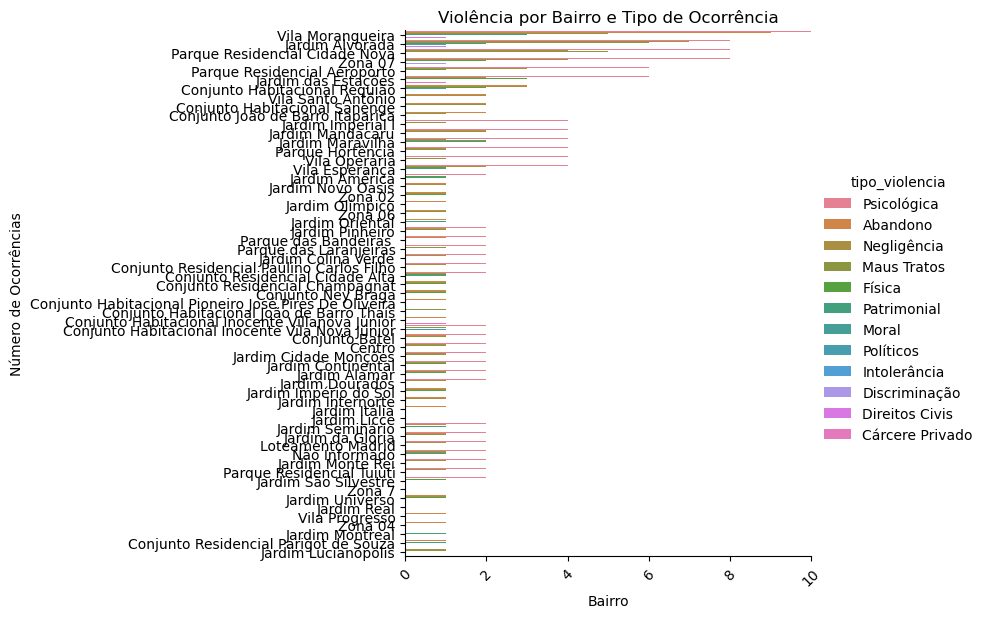

In [106]:
#plotando o gráfico com sns.catplot, com os dados agrupados, (tipo_violencia)[bairro]
#mas quando tento escolher as 40 observações com maior número, ele retira alguns tipos de violência
#no caso onde o tipo de violência pode não aparecer registrado no bairro
plt.figure(figsize=(15, 10))
sns.catplot(data=contagem_por_bairro, kind='bar', x='Total', y='bairro', hue='tipo_violencia', height=6, aspect=1.5)
plt.title('Violência por Bairro e Tipo de Ocorrência')
plt.ylabel('Número de Ocorrências')
plt.xlabel('Bairro')
plt.xlim(0, 10)
plt.xticks(rotation=45)
plt.show()

In [107]:
#fazendo uma tabela dinâmica para separar tipo_violência em colunas e preencher valores vazios com 0
#para quando colocar no gráfico, aparecerem todas as legendas de tipo_violencia, caso algum valor do recorte seja 0
df_pivot = contagem_por_bairro.pivot_table(
    index = 'bairro',
    columns='tipo_violencia',
    values='Total',
    aggfunc='sum',
    fill_value=0 
)
#criando uma coluna total, somando as oorrencias por bairro
df_pivot['Total'] = df_pivot.sum(axis=1)
#exportando o df para excel
df_pivot.to_excel('df_pivot_denuncias_2025.xlsx', index=True)
#ordenando os valores por total
df_sorted = df_pivot.sort_values(by='Total', ascending=True)
#excluindo a coluna total, para não aparecer no gráfico
df_plot = df_sorted.drop(columns=['Total'])

df_plot

tipo_violencia,Abandono,Cárcere Privado,Direitos Civis,Discriminação,Física,Intolerância,Maus Tratos,Moral,Negligência,Patrimonial,Políticos,Psicológica
bairro,,,,,,,,,,,,
Jardim Montreal,0,0,0,0,0,0,0,0,0,1,0,0
Jardim Real,0,0,0,0,0,0,0,0,0,1,0,0
Zona 7,0,0,0,0,0,0,0,0,0,0,0,2
Vila Progresso,1,0,0,0,0,0,0,0,1,0,0,0
Jardim Licce,0,0,0,0,0,0,0,0,0,0,0,2
Zona 04,1,0,0,0,1,0,0,0,1,0,0,0
Conjunto Habitacional João de Barro Thaís,0,0,0,0,0,0,1,0,0,0,0,2
Conjunto Residencial Parigot de Souza,1,0,0,0,0,0,0,0,1,1,0,0
Jardim Lucianópolis,1,0,0,0,1,0,1,0,1,0,0,0


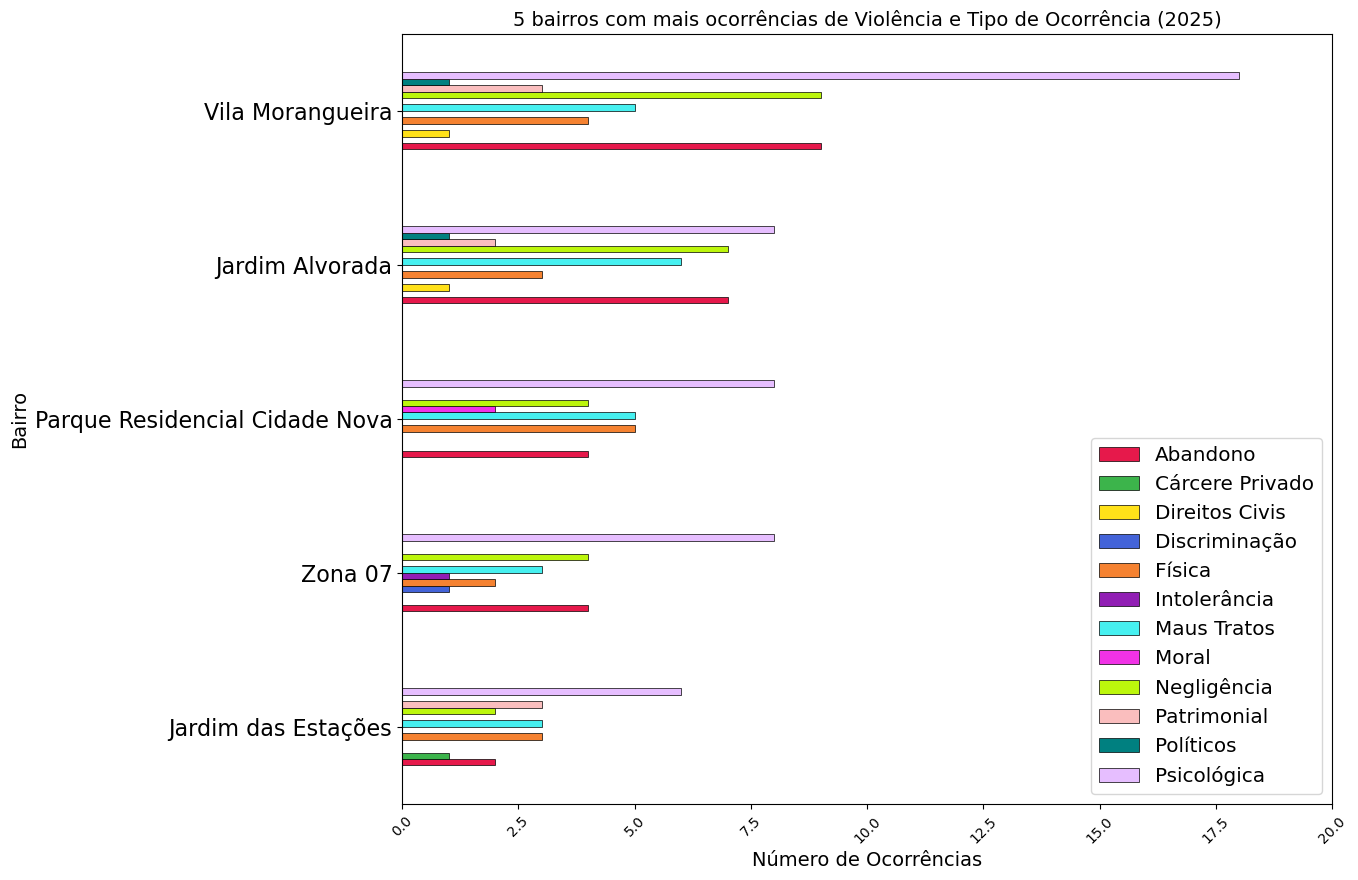

In [117]:
cores = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4',
    '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff'
]

ax = df_plot.tail(5).plot(kind='barh', figsize=(12,10), edgecolor='black', linewidth=0.5, color=cores)
plt.title('5 bairros com mais ocorrências de Violência e Tipo de Ocorrência (2025)', fontsize=14)
plt.ylabel('Bairro', fontsize=14)
plt.xlabel('Número de Ocorrências', fontsize=14)
plt.xlim(0, 10)
plt.xticks(rotation=45)
ax.tick_params(axis='y', labelsize=16)
ax.legend(fontsize='x-large')
ax.set_xlim(0, 20)
plt.savefig('denuncias-por-bairro-2025.png', dpi=300, bbox_inches='tight')


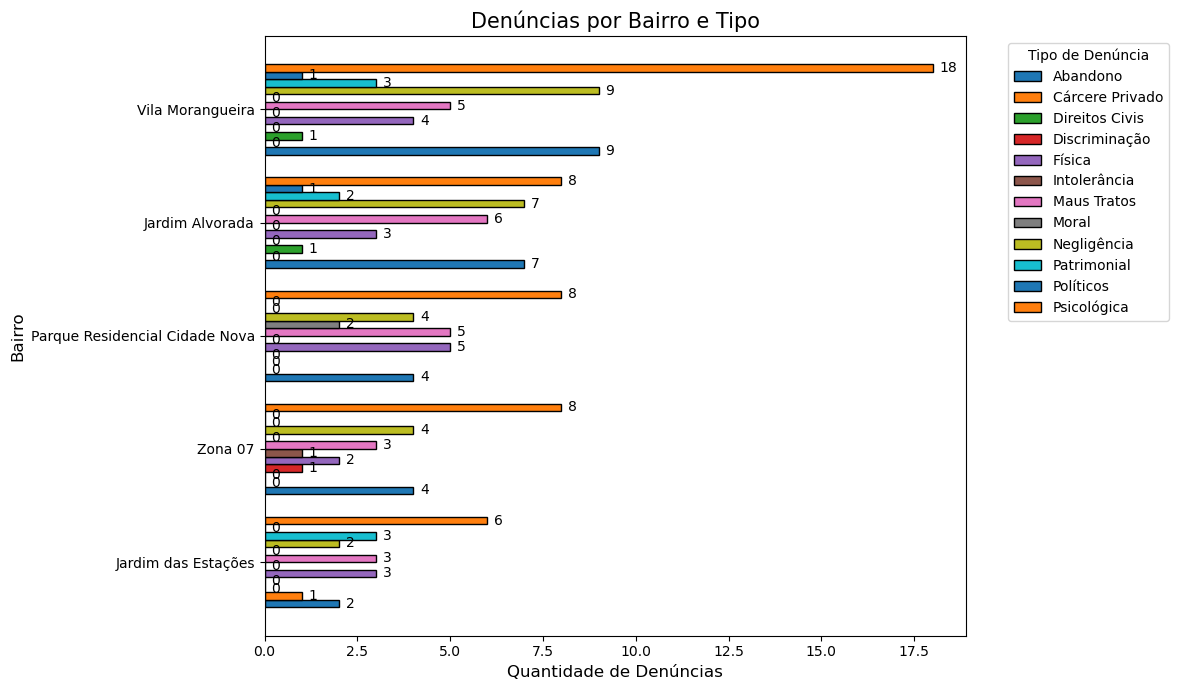

In [113]:
# 3. Criar o gráfico de barras
ax = df_plot.tail(5).plot(kind='barh', figsize=(12, 7), width=0.8, edgecolor='black')

# 4. Adicionar rótulos (labels) em cima das barras
for container in ax.containers:
    ax.bar_label(container, padding=5)

# 5. Personalizações
plt.title('Denúncias por Bairro e Tipo', fontsize=15)
plt.xlabel('Quantidade de Denúncias', fontsize=12)
plt.ylabel('Bairro', fontsize=12)
plt.xticks(rotation=0) # Mantém nomes dos bairros na horizontal
plt.legend(title='Tipo de Denúncia', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


[Text(5, 0, '0%'),
 Text(5, 0, '0%'),
 Text(5, 0, '0%'),
 Text(5, 0, '1%'),
 Text(5, 0, '1%'),
 Text(5, 0, '1%'),
 Text(5, 0, '6%'),
 Text(5, 0, '9%'),
 Text(5, 0, '13%'),
 Text(5, 0, '17%'),
 Text(5, 0, '17%'),
 Text(5, 0, '36%')]

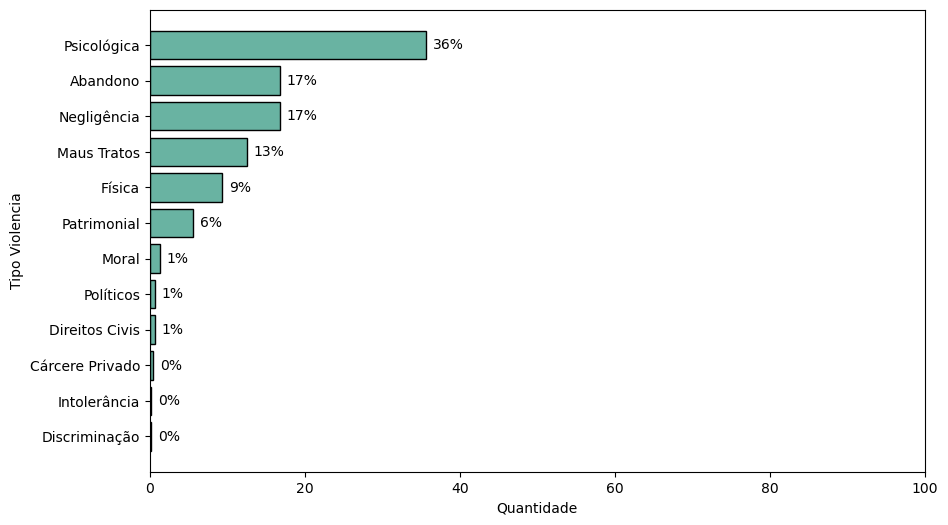

In [118]:
contagem = df_exp['tipo_violencia'].value_counts(normalize=True, ascending=True) * 100

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(contagem.index, contagem, color='#69b3a2', edgecolor = 'black')
ax.set_xlabel('Quantidade')
ax.set_ylabel('Tipo Violencia')
ax.set_xlim(0, 100)
ax.bar_label(ax.containers[0], fmt='%.0f%%', padding = 5)